# 4.1 — Probability as Counting, at the computer

Do the **pen-and-paper worksheet first**. This notebook is where the lesson's big claim goes on trial:
*probability is what the count settles to*. We'll flip and roll thousands of times and watch it happen.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

# A random-number generator. The 42 is the SEED — it makes the "random" numbers
# repeatable, so your results match these notes exactly. (Whole story in 4.4.)
rng = np.random.default_rng(42)

## 1. Watch a probability being born

Flip a coin 10,000 times and track the *running fraction of heads* — after 1 flip, after 2, after 3…

If "$P(\text{heads}) = 0.5$" means anything real, we should *see* it.

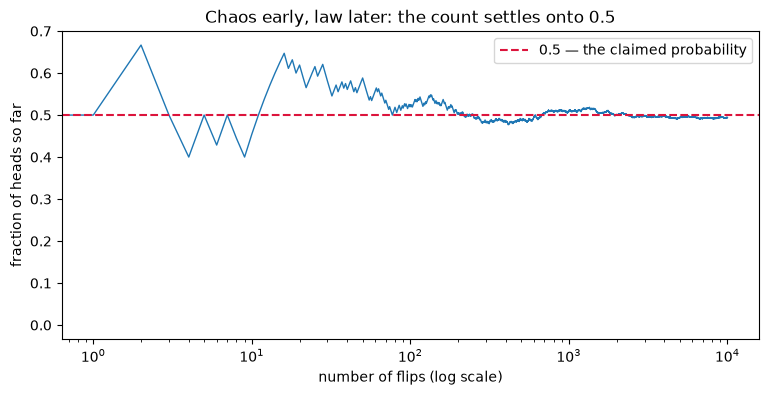

after    10 flips: 0.4
after 10000 flips: 0.4939


In [2]:
# rng.integers(low, high, size) draws whole numbers from low up to (NOT including) high.
flips = rng.integers(0, 2, size=10_000)          # 10,000 values, each 0 (tails) or 1 (heads)

heads_so_far = np.cumsum(flips)                  # cumsum = running total: [1, 1, 2, 3, 3, ...]
flip_number = np.arange(1, 10_001)               # arange = the counting numbers 1..10000
running_fraction = heads_so_far / flip_number    # fraction of heads after each flip

plt.figure(figsize=(9, 4))
plt.plot(running_fraction, linewidth=1)
plt.axhline(0.5, color="crimson", linestyle="--", label="0.5 — the claimed probability")
plt.xscale("log")                                # log x-axis: spreads out the wild early flips
plt.xlabel("number of flips (log scale)")
plt.ylabel("fraction of heads so far")
plt.title("Chaos early, law later: the count settles onto 0.5")
plt.legend()
plt.show()

print("after    10 flips:", running_fraction[9])
print("after 10000 flips:", running_fraction[-1])

Look at the left edge: after 10 flips the fraction can sit anywhere — 0.3, 0.7, who knows.
By 10,000 it's pinned near 0.5. **That settling-value is what "probability" means.**
The formula $\frac{1}{2}$ is a prediction about exactly this picture.

## 2. The dice from the worksheet, a million times

You counted $P(\text{sum}=7) = \frac{6}{36}$ by hand. Put the counting on trial:

simulated P(sum=7): 0.166706
your counted answer: 0.16666666666666666


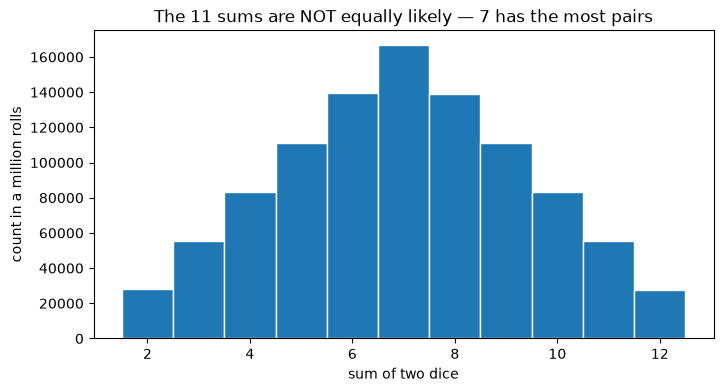

In [3]:
rolls = rng.integers(1, 7, size=(1_000_000, 2))   # a million PAIRS of dice (2 columns)
sums = rolls[:, 0] + rolls[:, 1]                  # [:, 0] = first column, [:, 1] = second

print("simulated P(sum=7):", (sums == 7).mean())  # True/False array -> mean = fraction of Trues
print("your counted answer:", 6 / 36)

# plt.hist draws a histogram: it counts how many values fall in each bin (bucket).
# bins=np.arange(1.5, 13.5) puts one bin around each whole sum 2, 3, ..., 12.
plt.figure(figsize=(8, 4))
plt.hist(sums, bins=np.arange(1.5, 13.5), edgecolor="white")
plt.xlabel("sum of two dice")
plt.ylabel("count in a million rolls")
plt.title("The 11 sums are NOT equally likely — 7 has the most pairs")
plt.show()

That triangle is your Part B counting, drawn: one pair makes a 2, six pairs make a 7.
(File the shape away — in 4.3, sums of *many* dice turn this triangle into something famous.)

## 3. Your turn

In [4]:
# YOUR TURN — first count on paper, THEN simulate. Prediction before peeking.
#
# a) P(both dice show an even number)?   Count the pairs: how many of the 36 qualify?
#    prediction_a = ?/36
# b) P(at least one six)?                (worksheet Part D, problem 13)
#
# Useful pieces:
#   rolls % 2 == 0                -> True where a die is even   (% is remainder-after-division)
#   (...).all(axis=1)             -> True where BOTH dice in a pair qualify
#   (rolls == 6).any(axis=1)      -> True where AT LEAST ONE die in a pair is a six

both_even = (rolls % 2 == 0).all(axis=1)
print("simulated P(both even):", both_even.mean())
# print("my counted prediction:", ?/36)

# b) build 'at_least_one_six' yourself, print it, compare with your Part D answer:


simulated P(both even): 0.250306


## 4. What you now own

Two ways to get any probability, and they must agree:

1. **Count** — favourable ÷ total (exact, needs cleverness)
2. **Simulate** — run it 1,000,000 times, take the mean (approximate, needs only honesty)

When a probability is too hairy to count, ML people simulate without shame. You now can too.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude. Next: 4.2 — mean, variance, and why ML normalises everything.*